# Main Project Notebook for Beamforming

## 1. Load Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.signal import stft, istft, spectrogram
from pathlib import Path
from scipy.signal import welch, decimate
from scipy.io import wavfile, loadmat
import pandas as pd

## 2. Setup

### Current dataset includes VLA and HLA data

In [2]:
# fs = 3276.8 #HLA
fs = 1500 #VLA
# nfft = 1028
nfft = 1028
hop = round(nfft/2)

### Load Data

In [3]:
# file_path = r"C:\Users\John Conrad\Desktop\ELEC5305\Real_Data\HLA_100000_SAMPLES.mat"
file_path = r"C:\Users\John Conrad\Desktop\ELEC5305\Real_Data\VLA_100000_SAMPLES.mat"
signal_array = loadmat(file_path)['ans'].T
signal_array = signal_array[::-1,:] # FOR VLA ONLY
mic_num = signal_array.shape[0]

### Load Microphone/Hydrophone Geometry

In [4]:
mic_pos = pd.read_excel(r"C:\Users\John Conrad\Desktop\ELEC5305\Real_Data\Hyd_Pos_VLA.xlsx",header=None).to_numpy()
mic_pos = mic_pos[:,1:4]

## 3. Data Check

### Check if Data Clipping

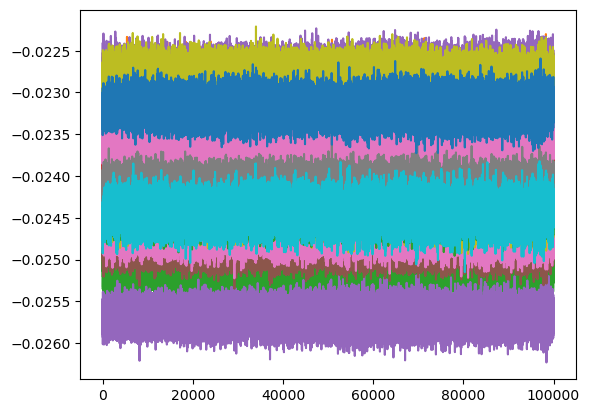

In [5]:
for i in range(signal_array.shape[0]):
    plt.plot(signal_array[i,:])

## 4. Compute Spectrogram

### Choose Window

In [6]:
# selected_window=("kaiser", 2)
selected_window='hann'

### Compute for each Hydrophone

In [7]:
# Compute Spectrogram for all channels
spectrogram_list = []
    
# for i in range(num_mic):
for i in range(mic_num):
    
    freq_bins, time_bins, X = stft(
    signal_array[i, :],
    fs=fs,
    window=selected_window,
    nperseg=nfft,
    noverlap=nfft - hop,
    nfft=nfft,
    return_onesided=True,
    boundary=None,
    padded=False,
    scaling='psd'
)
    
    spectrogram_list.append(X)
    
spectrogram_array = np.array(spectrogram_list)
del spectrogram_list

spectrogram_psd = np.abs(spectrogram_array)**2
spectrogram_psd[:,1:-1,:] *= 2

### Check Channel Spectrogram

In [8]:
selected_mic = 3

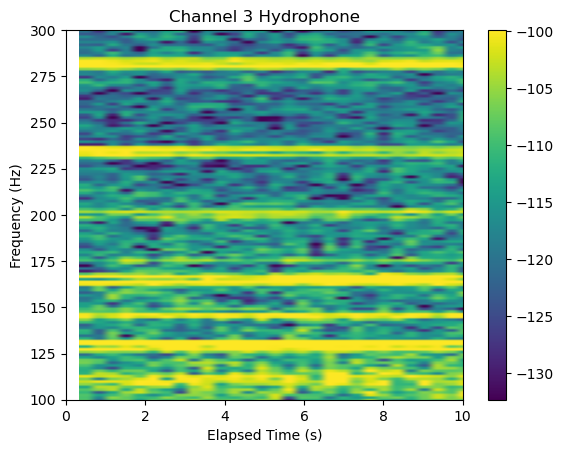

In [9]:
# Check Single Channel
plt.imshow(
    10*np.log10(spectrogram_psd[selected_mic,:,:]),
    aspect='auto',
    origin='lower',
    vmin = np.percentile(10*np.log10(spectrogram_psd[selected_mic,:,:]),5),
    vmax = np.percentile(10*np.log10(spectrogram_psd[selected_mic,:,:]),95),
    extent=[time_bins[0], time_bins[-1], freq_bins[0], freq_bins[-1]]
)

plt.title("Channel " + str(selected_mic) + " Hydrophone")
plt.xlabel("Elapsed Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar()
plt.ylim(0,500)
plt.xlim(0,10)
plt.ylim(100,300)
plt.show()

### Check Welch

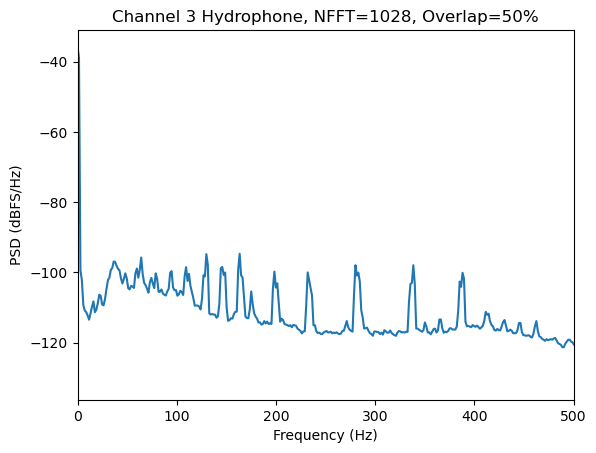

In [10]:
#Check Graph - for single microphone/hydrophone
f, Pxx = welch(signal_array[selected_mic,:], fs=fs, window=selected_window,
               nperseg=nfft, noverlap=nfft-hop, nfft=nfft, detrend=False)

plt.plot(f, 10*np.log10(Pxx))
plt.xlim(0,500)
# plt.ylim(-20,20)
plt.title("Channel " + str(selected_mic) + " Hydrophone, NFFT=" + str(nfft) + ", Overlap=50%")
plt.ylabel('PSD (dBFS/Hz)')
plt.xlabel("Frequency (Hz)")
plt.show()

## 5. Beamforming Setup

### Input Parameters

Choose a specific azimuth and elevation angle to input as well as speed for the sound.

In [11]:
c = 1500 #m/s
azi_deg = 0 #deg
ele_deg = 5 #deg
window_len = 10 # window size for creating covariance matrix (MVDR beamforming)

In [12]:
azi = np.deg2rad(azi_deg) #rad
ele = np.deg2rad(ele_deg) #rad

### Initialise Array

In [13]:
Y = np.zeros((len(freq_bins),len(time_bins)), dtype=np.complex128)
Y_mvdr = np.zeros((len(freq_bins),len(time_bins)), dtype=np.complex128)

### Calculate Time Delay (Tau)

In [14]:
# Unit vector
u = np.array([
    np.cos(ele) * np.sin(azi),
    np.cos(ele) * np.cos(azi),
    np.sin(ele)
    ])

In [15]:
# Time Delay
tau = -np.dot(mic_pos,u) / c

## 6. Perform Conventional Beamforming

In [16]:
for tt in range(len(time_bins)):
    for ff in range(len(freq_bins)):
        steering_vect = np.exp(-1j * 2 * np.pi* freq_bins[ff] * tau)
        Y[ff,tt] = np.dot(np.conj(steering_vect), spectrogram_array[:,ff,tt]) / mic_num

In [17]:
Y_psd = np.abs(Y)**2
Y_psd[1:-1] *= 2
Y_dB = 10*np.log10(Y_psd + 1e-12)

## 7. Perform MVDR Beamforming

In [18]:
for ff in range(len(freq_bins)):
    steering_vect = np.exp(-1j * 2 * np.pi * freq_bins[ff] * tau)
    steering_vect = steering_vect.reshape(-1, 1)

    for tt in range(len(time_bins)):
        start_idx = max(0, tt - window_len)
        end_idx = min(len(time_bins), tt + window_len)
        
        X_f = spectrogram_array[:, ff, start_idx:end_idx]
        R = (X_f @ X_f.conj().T) / X_f.shape[1]
        
        # loading = 1 * np.trace(R).real / mic_num
        loading = 0.1 * np.trace(R).real / mic_num
        R_loaded = R + loading * np.eye(mic_num)
        Rinv = np.linalg.inv(R_loaded)
        
        w = (Rinv @ steering_vect)/(steering_vect.conj().T @ Rinv @ steering_vect)                
        Y_mvdr[ff, tt] = np.dot(np.conj(w).flatten(), spectrogram_array[:, ff, tt])

In [19]:
Y_mvdr_psd = np.abs(Y_mvdr)**2
Y_mvdr_psd[1:-1] *= 2
Y_mvdr_dB = 10*np.log10(Y_mvdr_psd + 1e-12)

## 8. Compute Welch for Beamformer Outputs

In [20]:
#Check Graph - Beamformer & MVDR Output
spectrogram_avg_bf = np.mean(np.abs(Y)**2, axis=1)
spectrogram_avg_bf[1:-1] *= 2 

spectrogram_mvdr_avg_bf = np.mean(np.abs(Y_mvdr[:,:20])**2, axis=1)
spectrogram_mvdr_avg_bf[1:-1] *= 2 

## 9. Plot Welch Comparison

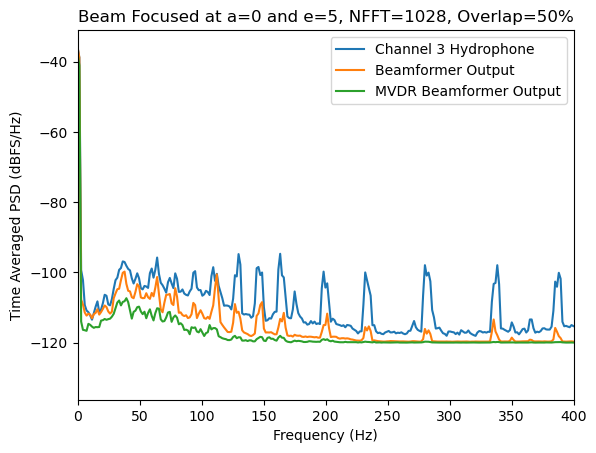

In [21]:
plt.plot(f, 10*np.log10(Pxx), label="Channel " + str(selected_mic) + " Hydrophone")
plt.plot(freq_bins, 10*np.log10(spectrogram_avg_bf + 1e-12), label="Beamformer Output")
plt.plot(freq_bins, 10*np.log10(spectrogram_mvdr_avg_bf + 1e-12), label="MVDR Beamformer Output")
plt.xlim(0,400)
# plt.ylim(-20,20)
plt.title(f"Beam Focused at a={azi_deg} and e={ele_deg}, NFFT=" + str(nfft) + ", Overlap=50%")
plt.ylabel('Time Averaged PSD (dBFS/Hz)')
plt.xlabel("Frequency (Hz)")
plt.legend()
plt.show()

## 10. Plot Spectrogram Comparison

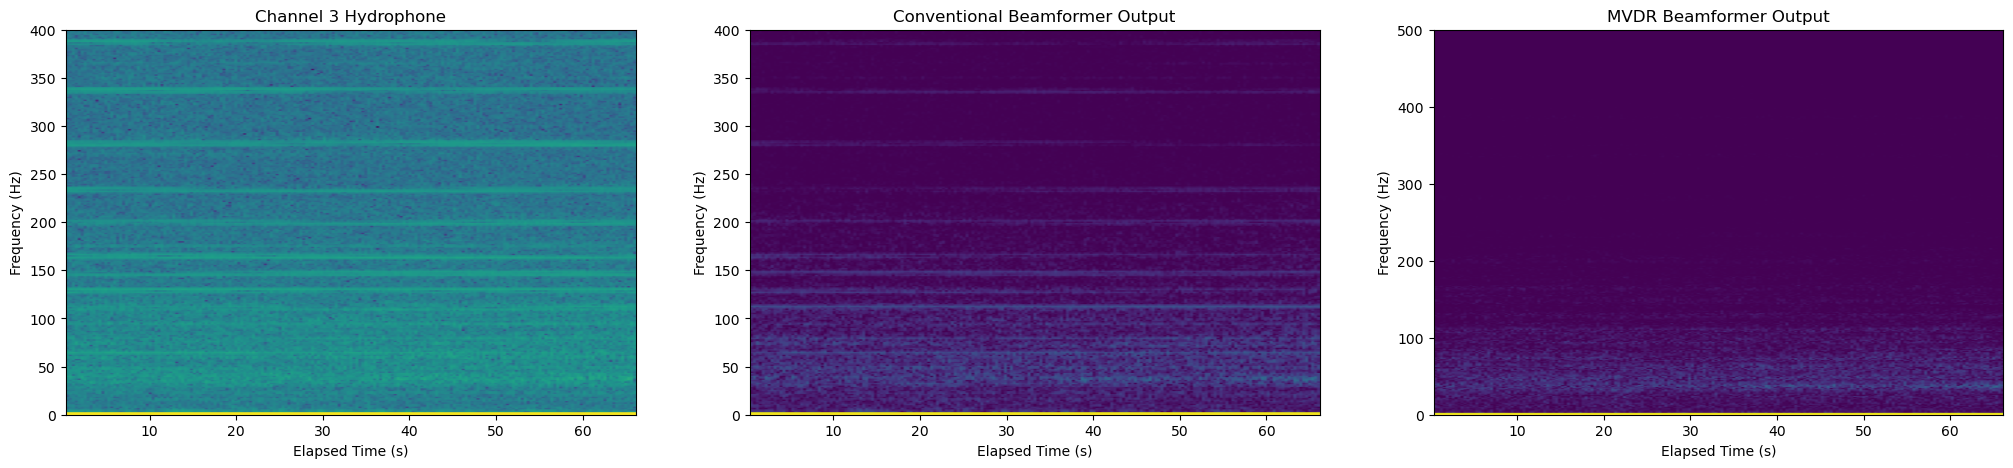

In [22]:
fig = plt.figure(figsize=(25, 5))
specgrid = GridSpec(nrows=1,ncols=3,figure=fig)
#------------------------------------------------------------------------------
# HYDROPHONE
ax1 = fig.add_subplot(specgrid[0])
ax1.imshow(
    10*np.log10(spectrogram_psd[selected_mic,:,:]),
    aspect='auto',
    origin='lower',
    # vmin = np.percentile(10*np.log10(spectrogram_psd[selected_mic,:,:]),5),
    # vmax = np.percentile(10*np.log10(spectrogram_psd[selected_mic,:,:]),95),
    extent=[time_bins[0], time_bins[-1],freq_bins[0], freq_bins[-1]]
)

ax1.set_ylim(0,400)
ax1.set_title("Channel " + str(selected_mic) + " Hydrophone")
ax1.set_xlabel("Elapsed Time (s)")
ax1.set_ylabel("Frequency (Hz)")
#------------------------------------------------------------------------------
# BF
ax2 = fig.add_subplot(specgrid[1])
ax2.imshow(
    Y_dB,
    aspect='auto',
    origin='lower',
    # vmin = np.percentile(Y_dB,5),
    # vmax = np.percentile(Y_dB,95),
    extent=[time_bins[0], time_bins[-1],freq_bins[0], freq_bins[-1]]
)

ax2.set_ylim(0,400)
ax2.set_title("Conventional Beamformer Output")
ax2.set_xlabel("Elapsed Time (s)")
ax2.set_ylabel("Frequency (Hz)")
#------------------------------------------------------------------------------
# MVDR BF
ax3 = fig.add_subplot(specgrid[2])
ax3.imshow(
    Y_mvdr_dB,
    aspect='auto',
    origin='lower',
    # vmin = np.percentile(Y_dB,5),
    # vmax = np.percentile(Y_dB,95),
    extent=[time_bins[0], time_bins[-1],freq_bins[0], freq_bins[-1]]
)

ax3.set_ylim(0,500)
ax3.set_title("MVDR Beamformer Output")
ax3.set_xlabel("Elapsed Time (s)")
ax3.set_ylabel("Frequency (Hz)")

plt.show()